In [1]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Titanic.csv')

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.columns = df.columns.str.lower()

In [5]:
df.columns = df.columns.str.replace('passengerid' , 'passenger_id')

In [6]:
df.columns = [ 'passenger_id' , 'survived' , 'p_class' , 'name' , 'sex' , 'age' , 'sibsp' , 'parch' , 'ticket' , 'fare' , 'cabin' , 'embarked' ]

In [7]:
df

,passenger_id,survived,p_class,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [8]:
df.isnull().sum()

passenger_id      0
survived          0
p_class           0
name              0
sex               0
age             177
sibsp             0
parch             0
ticket            0
fare              0
cabin           687
embarked          2
dtype: int64

In [9]:
df = df.drop(columns = ['cabin'])

In [10]:
(df['age'].isnull().sum() / len(df)) * 100

np.float64(19.865319865319865)

In [11]:
# df['age'] = df['age'].fillna(df['age'].median())
df['age'] = df.groupby('p_class')['age'].transform(
    lambda x : x.fillna(x.median())
)

In [12]:
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

In [13]:
df.isnull().sum()

passenger_id    0
survived        0
p_class         0
name            0
sex             0
age             0
sibsp           0
parch           0
ticket          0
fare            0
embarked        0
dtype: int64

In [14]:
df['embarked'] = df['embarked'].replace({'S':'England' , 'C' : 'France' , 'Q' : 'lreland'})

In [15]:
df

,passenger_id,survived,p_class,name,sex,age,sibsp,parch,ticket,fare,embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,England
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,France
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,England
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,England
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,England
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,England
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,England
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,24.0,1,2,W./C. 6607,23.4500,England
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,France


In [16]:
df['embarked'].unique()

array(['England', 'France', 'lreland'], dtype=object)

In [17]:
for col in df.columns:
    if df[col].nunique() < 20 :
        print(df[col].value_counts())
        print('_'*50)
    

survived
0    549
1    342
Name: count, dtype: int64
__________________________________________________
p_class
3    491
1    216
2    184
Name: count, dtype: int64
__________________________________________________
sex
male      577
female    314
Name: count, dtype: int64
__________________________________________________
sibsp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64
__________________________________________________
parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64
__________________________________________________
embarked
England    646
France     168
lreland     77
Name: count, dtype: int64
__________________________________________________


In [18]:
df['age'] = df['age'].astype('int64')

In [19]:
df['age'].mean().round()

np.float64(29.0)

In [20]:
df.groupby('sex')['age'].mean().round()

sex
female    28.0
male      30.0
Name: age, dtype: float64

In [21]:
df['fare'].min() , df['fare'].max()

(0.0, 512.3292)

In [22]:
df['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

([<matplotlib.axis.XTick at 0x192c722e7b0>,
 [Text(0, 0, 'non-survival '), Text(1, 0, 'survival')])

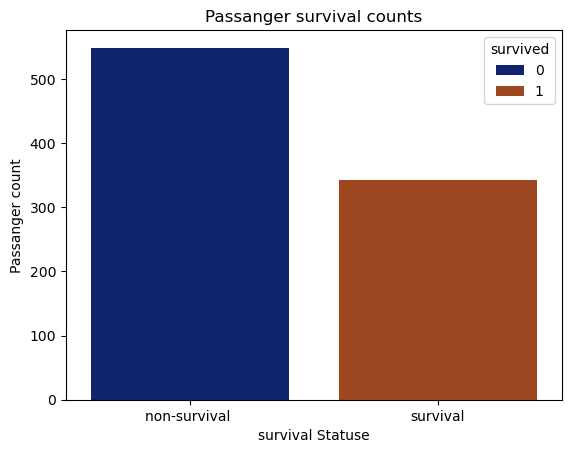

In [23]:
sb.countplot(
    data=df , 
    x = 'survived' ,
    hue = 'survived' ,
    palette = 'dark' ,
    # legend = False
)

plt.title('Passanger survival counts')
plt.xlabel('survival Statuse')
plt.ylabel('Passanger count')
plt.xticks([0,1] , [ 'non-survival ' , 'survival' ] )

In [24]:
df['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

Text(0.5, 1.0, 'male vs female passengers ')

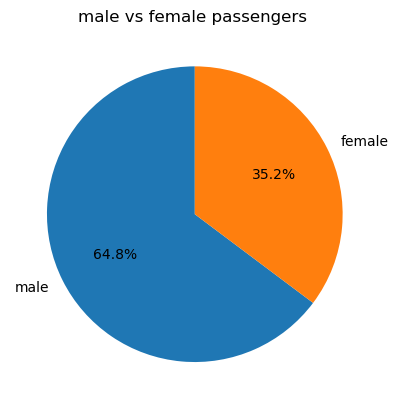

In [25]:
gender = df['sex'].value_counts()

plt.pie(
    x = gender ,
    labels = gender.index ,
    autopct = '%1.1f%%' ,
    startangle = 90
)
plt.title('male vs female passengers ')

In [26]:
df.sample(6)

,passenger_id,survived,p_class,name,sex,age,sibsp,parch,ticket,fare,embarked
511,512,0,3,"Webber, Mr. James",male,24,0,0,SOTON/OQ 3101316,8.0500,England
65,66,1,3,"Moubarek, Master. Gerios",male,24,1,1,2661,15.2458,France
213,214,0,2,"Givard, Mr. Hans Kristensen",male,30,0,0,250646,13.0000,England
312,313,0,2,"Lahtinen, Mrs. William (Anna Sylfven)",female,26,1,1,250651,26.0000,England
387,388,1,2,"Buss, Miss. Kate",female,36,0,0,27849,13.0000,England
185,186,0,1,"Rood, Mr. Hugh Roscoe",male,37,0,0,113767,50.0000,England


In [27]:
#12. Find the average Fare for each Passenger Class.

df.groupby('p_class')['fare'].mean()

#12. Find the average Fare for each Passenger Class.

df.groupby('p_class')['age'].mean()

p_class
1    38.055556
2    29.804348
3    24.806517
Name: age, dtype: float64

In [28]:
# 14. Find the number of passengers who embarked from each port.

df.groupby('embarked').size()

embarked
England    646
France     168
lreland     77
dtype: int64

In [29]:
df['embarked'].value_counts()

embarked
England    646
France     168
lreland     77
Name: count, dtype: int64

<Axes: xlabel='embarked', ylabel='count'>

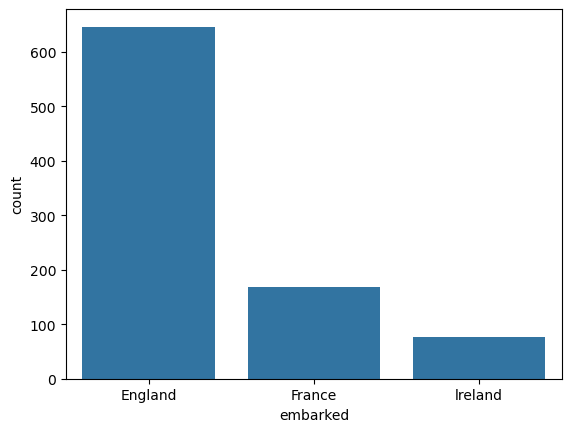

In [30]:
#15. Plot a bar chart of passengers by Embarked port.

sb.countplot(
    data = df ,
    x = 'embarked'
)

In [31]:
df['embarked'].value_counts()

embarked
England    646
France     168
lreland     77
Name: count, dtype: int64

In [32]:
# 16. outliers      (   method : interquartilr range   )

q1 = df['fare'].quantile(0.25)
q3 = df['fare'].quantile(0.75)

IQR = q3 - q1 

lower_limit = q1 - 1.5 * IQR
upper_limit = q3 + 1.5 * IQR

df = df[(df['fare'] >= lower_limit) & (df['fare'] <= upper_limit)]

<Axes: xlabel='age', ylabel='Count'>

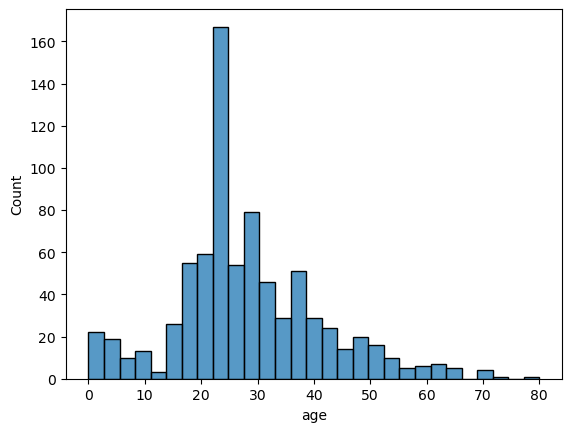

In [33]:
# 17. histogram graph

sb.histplot(
    data = df ,
    x = 'age' ,
)

In [34]:
df[df['age'] == 0]

,passenger_id,survived,p_class,name,sex,age,sibsp,parch,ticket,fare,embarked
78,79,1,2,"Caldwell, Master. Alden Gates",male,0,0,2,248738,29.0000,England
469,470,1,3,"Baclini, Miss. Helene Barbara",female,0,2,1,2666,19.2583,France
644,645,1,3,"Baclini, Miss. Eugenie",female,0,2,1,2666,19.2583,France
755,756,1,2,"Hamalainen, Master. Viljo",male,0,1,1,250649,14.5000,England
803,804,1,3,"Thomas, Master. Assad Alexander",male,0,0,1,2625,8.5167,France
831,832,1,2,"Richards, Master. George Sibley",male,0,1,1,29106,18.7500,England


In [35]:
len(df)

775

Text(0.5, 1.0, 'Age vs Fare')

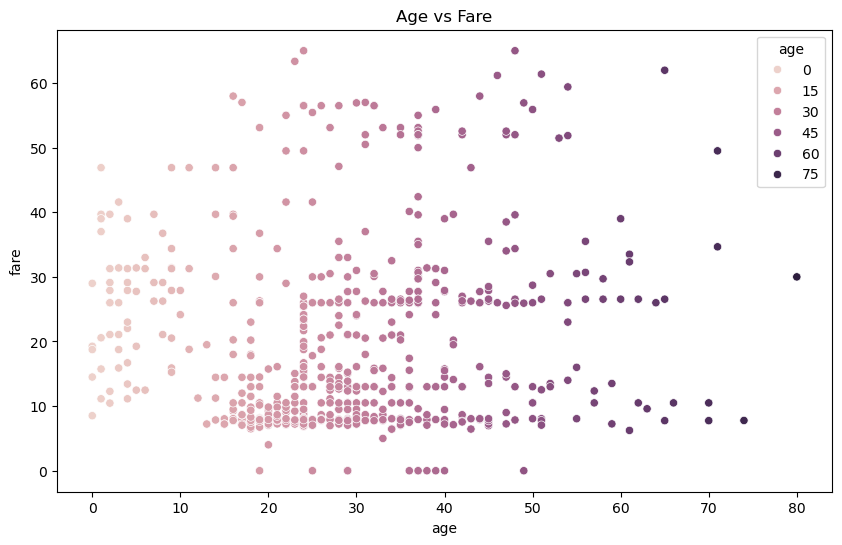

In [36]:
# 18. Draw a scatter plot of Age vs Fare.

plt.figure(figsize=(10,6))
sb.scatterplot(
    data = df ,
    x = "age" , 
    y = "fare" , 
    hue='age'
)
plt.title('Age vs Fare')

In [37]:
df.groupby('p_class').agg(
    Average_Age = ('age','mean') ,
    Average_Fare = ('fare','mean') ,
    Survival_Rate = ('survived','mean')
    
)

,Average_Age,Average_Fare,Survival_Rate
p_class,,,
1,40.892857,37.052978,0.508929
2,29.988827,19.186266,0.486034
3,24.818182,12.867449,0.245868


In [38]:
df.groupby('embarked').agg(
    survived_rate = ('survived' , 'count')
).head(1)

,survived_rate
embarked,
England,584


In [39]:
df.groupby('p_class')['survived'].mean().sort_values(ascending=False).sort_values(ascending=False)

p_class
1    0.508929
2    0.486034
3    0.245868
Name: survived, dtype: float64

In [40]:
df.groupby('sex')['survived'].mean().sort_values(ascending=False).sort_values(ascending=False)

sex
female    0.688525
male      0.178908
Name: survived, dtype: float64

In [41]:
df.groupby('embarked')['survived'].mean().sort_values(ascending=False).sort_values(ascending=False)

embarked
France     0.448276
lreland    0.386667
England    0.311644
Name: survived, dtype: float64

In [42]:
df.groupby('survived')['fare'].mean().round(2)

survived
0    15.54
1    22.26
Name: fare, dtype: float64

In [43]:
df.loc[df['survived'] == 1 , 'fare'].mean().round(2)

np.float64(22.26)

In [44]:
df.groupby('survived')['age'].mean().round(2)

survived
0    29.33
1    26.40
Name: age, dtype: float64

In [45]:
df.loc[df['survived'] == 1 , 'age'].mean().round(2)

np.float64(26.4)

In [46]:
df = df[(df['age'] >= lower_limit) & (df['age'] <= upper_limit)].copy()

df['age_group'] = pd.cut(
    df['age'] ,
    bins = [ 0 , 12 , 18 , 35 , 60 , 100] ,
    labels = ['child' , 'teen' , 'adult young' , 'young' , 'senior']
)

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 768 entries, 0 to 890
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   passenger_id  768 non-null    int64   
 1   survived      768 non-null    int64   
 2   p_class       768 non-null    int64   
 3   name          768 non-null    object  
 4   sex           768 non-null    object  
 5   age           768 non-null    int64   
 6   sibsp         768 non-null    int64   
 7   parch         768 non-null    int64   
 8   ticket        768 non-null    object  
 9   fare          768 non-null    float64 
 10  embarked      768 non-null    object  
 11  age_group     762 non-null    category
dtypes: category(1), float64(1), int64(6), object(4)
memory usage: 73.0+ KB


In [48]:
df.groupby('age_group' , observed=False)['survived'].mean().round(2).sort_values(ascending=False).head(1)

age_group
child    0.53
Name: survived, dtype: float64

In [49]:
df.groupby('p_class')['fare'].sum().idxmax()

np.int64(3)

In [50]:
df.groupby('survived')['fare'].mean()

survived
0    15.488066
1    22.230822
Name: fare, dtype: float64

In [51]:
df.loc[df['age_group'] == 'senior']['p_class']

54     1
170    1
252    1
280    3
326    3
456    1
483    3
545    1
555    1
570    2
625    1
Name: p_class, dtype: int64

In [52]:
df.groupby('p_class')['age_group'].value_counts()

p_class  age_group  
1        young           70
         adult young     29
         senior           7
         teen             3
         child            0
2        adult young    101
         young           47
         child           14
         teen            11
         senior           1
3        adult young    327
         young           58
         teen            46
         child           45
         senior           3
Name: count, dtype: int64

In [53]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

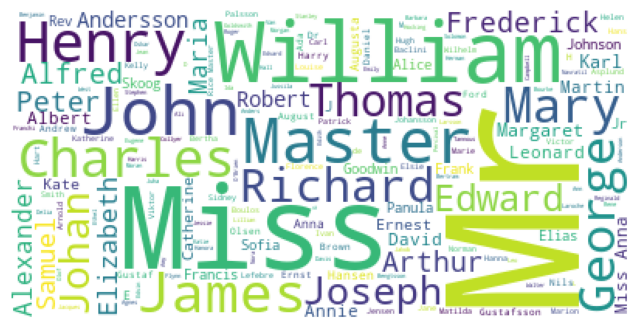

In [56]:
from wordcloud import WordCloud

text = " ".join(df['name'].dropna())

wd = WordCloud(
    width=400,
    height=200,
    background_color='white',
).generate(text)

plt.figure(figsize=(8,6))
plt.imshow(wd)
plt.axis('off')

In [55]:
df.sample(20)

,passenger_id,survived,p_class,name,sex,age,sibsp,parch,ticket,fare,embarked,age_group
596,597,1,2,"Leitch, Miss. Jessie Wills",female,29,0,0,248727,33.0000,England,adult young
298,299,1,1,"Saalfeld, Mr. Adolphe",male,37,0,0,19988,30.5000,England,young
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58,0,0,113783,26.5500,England,young
370,371,1,1,"Harder, Mr. George Achilles",male,25,1,0,11765,55.4417,France,adult young
121,122,0,3,"Moore, Mr. Leonard Charles",male,24,0,0,A4. 54510,8.0500,England,adult young
344,345,0,2,"Fox, Mr. Stanley Hubert",male,36,0,0,229236,13.0000,England,young
415,416,0,3,"Meek, Mrs. Thomas (Annie Louise Rowley)",female,24,0,0,343095,8.0500,England,adult young
653,654,1,3,"O'Leary, Miss. Hanora ""Norah""",female,24,0,0,330919,7.8292,lreland,adult young
57,58,0,3,"Novel, Mr. Mansouer",male,28,0,0,2697,7.2292,France,adult young
239,240,0,2,"Hunt, Mr. George Henry",male,33,0,0,SCO/W 1585,12.2750,England,adult young
